# GTEx LORO Tensor Reconstructions — Single

Standalone single-tensor renders of the held-out `loro_truth` and its
reconstruction `loro_recon`, on the matched native-GTEx-parcel axis
(`region_matched`). Region ticks are dense (`REGION_TICK_STEP=1`) so every
parcel is labeled. Dense `loro_fused` / `fullfit` and all AHBA joint renders
live in `eval_gxp_samples_predictions_joint.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.eval_utils.eval_style import set_academic_style
from src.eval_utils.eda_core import prepare_pre_post_harmonization_cached
from src.eval_utils.results_eda import EDAConfig

from src.eval_utils.eval_flattened import (
    build_donor_median_flattened_matrix,
    build_flattened_tensor_matrix,
    build_paired_flattened_tensor_matrices,
    gene_correlation_table,
    plot_flattened_tensor_matrices,
    plot_flattened_tensor_pair,
    reconstruction_summary,
    sample_correlation_table,
)
from src.eval_utils.eval_samples import (
    MatchingContext,
    build_combat_tensor_view,
    build_prediction_tensor_view,
    plot_gtex_tensor_voxels,
)

set_academic_style()

In [2]:
SMALL = True

# Cache pointer must match cfg below: cache_root encodes the matching policy.
#   loro_subject_cache_cv → centroids_and_volumes
#   loro_subject_cache_c  → centroids
CACHE_ROOT = 'out/loro_subject_cache_cv'
MODEL_NAME = 'dlam'    # active model for standalone 3D tensor renders
GENE_SCOPE = 'allgenes'

CSV_PATH = 'data/raw/gxp_samples.csv'   # caches were built against the full CSV
ACTIVE_GENE_LIST = 'richiardi2015'        # post-cube gene-axis filter; None keeps all

MATCHING_POLICY = 'centroids_and_volumes'
MATCHING_POLICY_HEMI_MODE = 'force_left'
GTEX_REP_MODE = 'centroid'
GTEX_HEMI_MODE = 'mirror_left'
COLLAPSE_CEREBELLUM = False
MIN_OBSERVED_PARCELS = 5
COMBAT_USE_COVARIATES = True

# Region axis: matched native-GTEx parcels only (no AHBA-only superset block).
REGION_ORDERING = 'region_matched'

# Subsampling.
N_GTEX_SUBJECTS = 40 if SMALL else 200
N_AHBA_SUBJECTS = 6
N_GENES = 100 if SMALL else None
N_REGIONS = 80 if SMALL else None
RANDOM_SEED = 42

# Pre-filter subject list before loading (avoids stacking the full ~300 npz files).
import random as _random
_random.seed(RANDOM_SEED)
_all_subjects = sorted(p.stem for p in (Path(CACHE_ROOT) / GENE_SCOPE / MODEL_NAME).glob('*.npz'))
if SMALL and N_GTEX_SUBJECTS < len(_all_subjects):
    SUBJECTS_TO_LOAD = sorted(_random.sample(_all_subjects, N_GTEX_SUBJECTS))
else:
    SUBJECTS_TO_LOAD = None
print(f'npz subjects available: {len(_all_subjects)}; loading: '
      f'{len(SUBJECTS_TO_LOAD) if SUBJECTS_TO_LOAD else len(_all_subjects)}')

# Standalone single-tensor stages: held-out truth and its reconstruction.
STAGES = ('loro_truth', 'loro_recon')
STAGE_TITLES = {
    'loro_truth':  'LORO truth (held-out)',
    'loro_recon':  'LORO recon (held-out predictions)',
}

# Render knobs (same as combat notebook for A/B comparability)
MISSING_ALPHA = 1.0
# First pass: no translucency — extrapolated predictions render fully opaque.
# Titrate this < 1.0 later to encode prediction uncertainty.
FUTURE_IMPUTATION_ALPHA = 1.0
MASK_RENDER_MODE = 'two_pass'
FIGSIZE = 'auto'
AXES_BBOX = 'auto'
COLORBAR_BBOX = 'auto'
BOX_ASPECT = 'compressed_data'
BOX_ZOOM = 1
DPI = 300 if SMALL else 400
TITLE_PAD = 0.0
AXIS_ASSIGNMENT = ('gene', 'region', 'subject')
ELEV = 20.0
AZIM = 24.0
SUBJECT_TICK_STEP = 2
GENE_TICK_STEP = 10
REGION_TICK_STEP = 1
TICK_LABEL_PAD = -3.0
SUBJECT_LABEL_MODE = 'full'
GENE_LABEL_MODE = 'full'
SHOW_X_AXIS_LABEL = True
SHOW_Y_AXIS_LABEL = None
SHOW_Z_AXIS_LABEL = None
SHOW_AXIS_LABELS = False
SHOW_SUBJECT_TICKLABELS = True
SHOW_REGION_TICKLABELS = True
SHOW_REGION_LABEL_COLORS = False
SHOW_GENE_TICKLABELS = False
SHOW_AXIS_LINES = True
SHOW_TICK_LINES = True
SHOW_GRID = False
SHOW_LEGEND = True


npz subjects available: 318; loading: 40


## Load PREPOST + MatchingContext

`MatchingContext` supplies the parcel/gene axes that label the prediction cubes. No AHBA reference is needed for the single-tensor renders.

In [3]:
cfg = EDAConfig(
    csv_path=CSV_PATH,
    cache_root=CACHE_ROOT,
    gene_scope=GENE_SCOPE,
    min_observed_parcels=MIN_OBSERVED_PARCELS,
    combat_use_covariates=COMBAT_USE_COVARIATES,
    gtex_rep_mode=GTEX_REP_MODE,
    gtex_hemi_mode=GTEX_HEMI_MODE,
    matching_policy=MATCHING_POLICY,
    matching_policy_hemi_mode=MATCHING_POLICY_HEMI_MODE,
    collapse_cerebellum=COLLAPSE_CEREBELLUM,
)
prepost = prepare_pre_post_harmonization_cached(cfg)
ctx = MatchingContext.from_cfg(cfg, prepost)
print(f'target parcels: {len(ctx.regions_full)}, genes: {len(ctx.genes_full)}')
print(f'matching policy: {ctx.matching["policy"]!r} hemi={ctx.matching["hemi_mode"]!r}')

[prepost_cache] hit  notebooks/cache/prepost/0f8616c23cf88e0f.pkl  (8961.2 MB)


/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:356: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


target parcels: 150, genes: 11704
matching policy: 'centroids_and_volumes' hemi='force_left'


## Build GTEx single-tensor prediction views

In [4]:
tier_b_kwargs = dict(
    cfg=cfg,
    matching_context=ctx,
    region_ordering=REGION_ORDERING,
    gene_panel=ACTIVE_GENE_LIST,
    n_regions=N_REGIONS,
    n_genes=N_GENES,
    random_seed=RANDOM_SEED,
)

# GTEx single-tensor views (matched axis), one per held-out stage.
gtex_views = {}
for stage in STAGES:
    gtex_views[stage] = build_prediction_tensor_view(
        CACHE_ROOT, MODEL_NAME,
        dataset='GTEx', stage=stage,
        subjects=SUBJECTS_TO_LOAD,
        n_subjects=N_GTEX_SUBJECTS,
        **tier_b_kwargs,
    )

for stage, v in gtex_views.items():
    n_obs = int(v.observed_mask.sum())
    print(f'{stage:12s}: values={v.values.shape}, axis_kind={v.region_axis_kind}, obs_cells={n_obs}')

loro_truth  : values=(40, 12, 97), axis_kind=ahba_parcel, obs_cells=358
loro_recon  : values=(40, 12, 97), axis_kind=ahba_parcel, obs_cells=358


## Standalone GTEx single-dataset renders

In [5]:
# Render helpers — one tensor per cell below (no plot loops).
_COMMON = dict(
    missing_rgba=(0.78, 0.78, 0.78, MISSING_ALPHA),
    future_imputation_rgba=(0.78, 0.78, 0.78, FUTURE_IMPUTATION_ALPHA),
    figsize=FIGSIZE, dpi=DPI, axes_bbox=AXES_BBOX, colorbar_bbox=COLORBAR_BBOX,
    box_aspect=BOX_ASPECT, box_zoom=BOX_ZOOM, title_pad=TITLE_PAD,
    axis_assignment=AXIS_ASSIGNMENT, elev=ELEV, azim=AZIM,
    subject_tick_step=SUBJECT_TICK_STEP, gene_tick_step=GENE_TICK_STEP,
    region_tick_step=REGION_TICK_STEP, tick_label_pad=TICK_LABEL_PAD,
    subject_label_mode=SUBJECT_LABEL_MODE, gene_label_mode=GENE_LABEL_MODE,
    show_x_axis_label=SHOW_X_AXIS_LABEL, show_y_axis_label=SHOW_Y_AXIS_LABEL,
    show_z_axis_label=SHOW_Z_AXIS_LABEL, show_axis_labels=SHOW_AXIS_LABELS,
    show_subject_ticklabels=SHOW_SUBJECT_TICKLABELS,
    show_region_ticklabels=SHOW_REGION_TICKLABELS,
    show_region_label_colors=SHOW_REGION_LABEL_COLORS,
    show_gene_ticklabels=SHOW_GENE_TICKLABELS,
    show_axis_lines=SHOW_AXIS_LINES, show_tick_lines=SHOW_TICK_LINES,
    show_grid=SHOW_GRID, mask_render_mode=MASK_RENDER_MODE,
)

def _breakdown(view):
    ns, nr, ng = view.values.shape
    return f'{ns} subjects x {nr} regions x {ng} genes'

def render_standalone(stage):
    fig, ax = plot_gtex_tensor_voxels(gtex_views[stage], show_legend=False, **_COMMON)
    ax.set_title(f'GTEx {STAGE_TITLES[stage]}  ({_breakdown(gtex_views[stage])})', pad=float(TITLE_PAD))
    plt.show()
    return ax

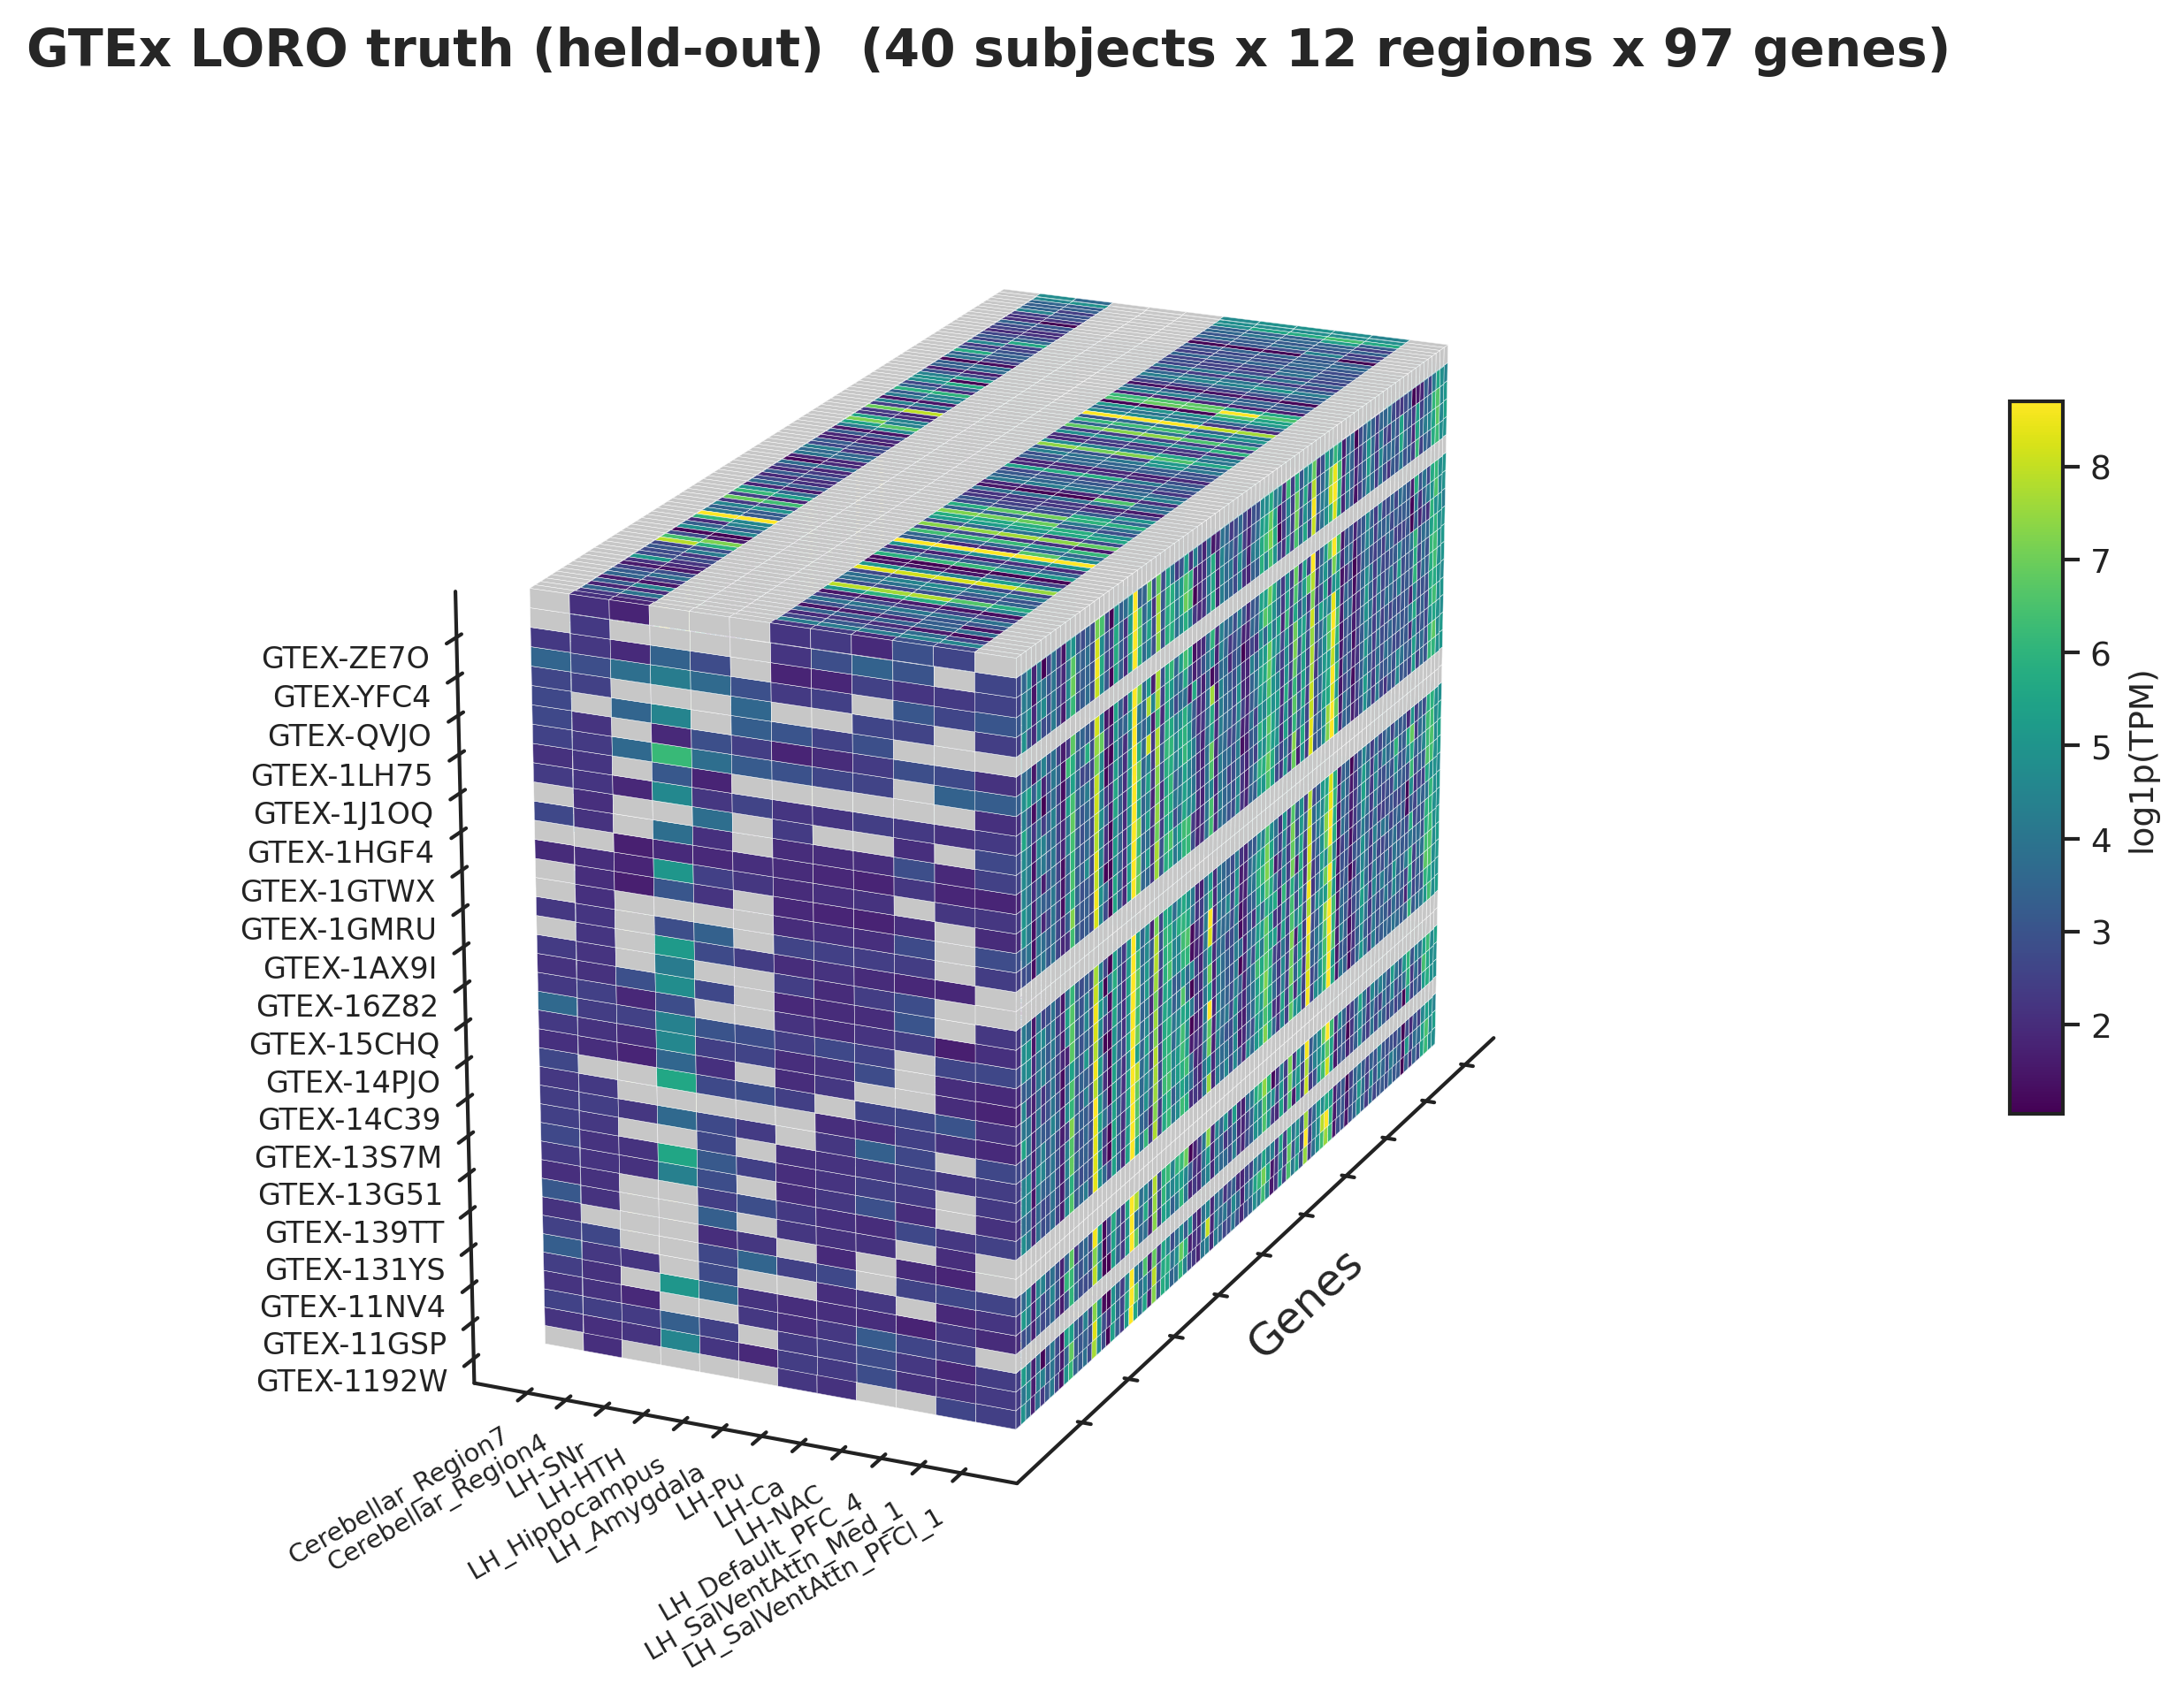

<Axes3D: title={'center': 'GTEx LORO truth (held-out)  (40 subjects x 12 regions x 97 genes)'}, xlabel='Genes'>

In [6]:
render_standalone('loro_truth')

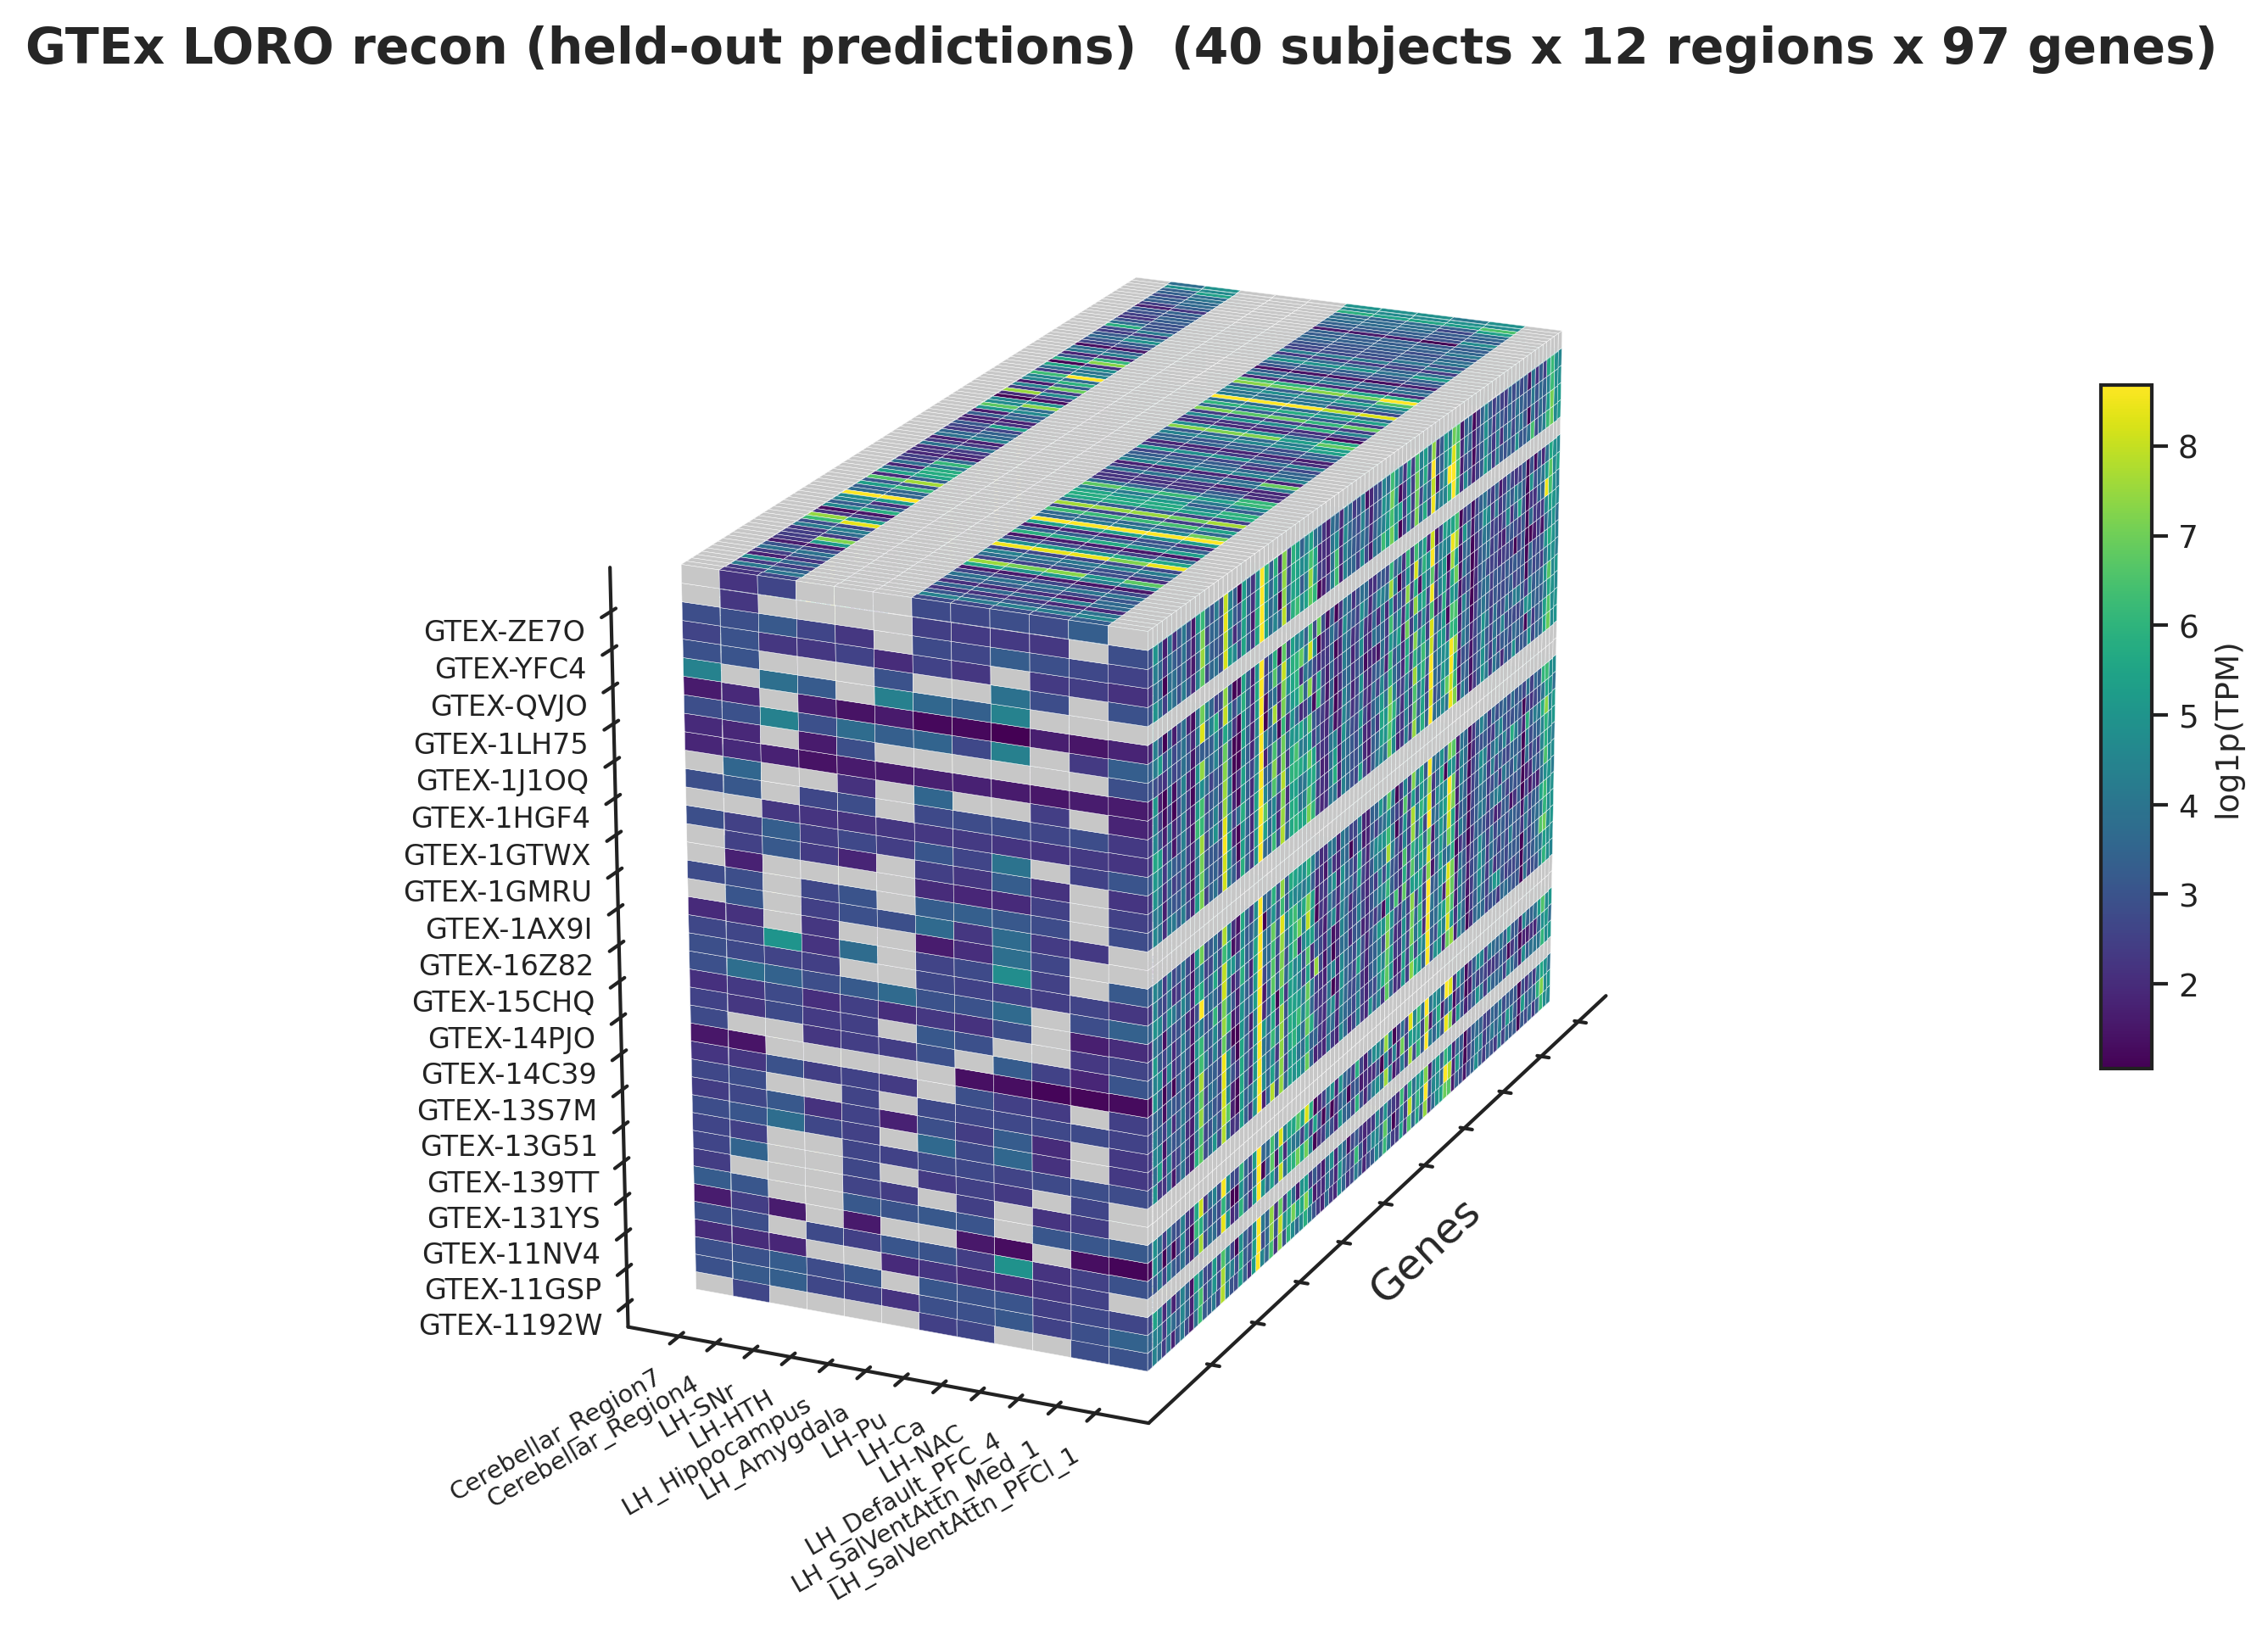

<Axes3D: title={'center': 'GTEx LORO recon (held-out predictions)  (40 subjects x 12 regions x 97 genes)'}, xlabel='Genes'>

In [7]:
render_standalone('loro_recon')

## Truth vs reconstruction matrices

Subject-sorted Truth↔Recon rectangular matrices, one section per model (DLAM, Naive), rendered with one shared `MX_*` style. Rows are subject-region samples grouped by subject (set `MX_SORT_BY='region'` to group by region instead); columns are genes. Thick separators delineate the distinct units (subjects, or regions).

In [8]:
# === Truth vs reconstruction matrices — shared style/config ===
MX_SORT_BY = 'subject'         # row grouping: 'subject' (default) | 'region'
MX_MODELS = ('dlam', 'naive')
MX_N_SUBJECTS = 8 if SMALL else 200
MX_GENE_PANEL = 'gtex_10deg'   # 'gtex_10deg' | 'gtex_100hvg' | 'richiardi2015' | None (all)
MX_N_GENES = 6 if SMALL else None
MX_RANDOM_SEED = 42

# Subject prefilter (enumerate from the first model's cache).
import random as _mx_random
_mx_random.seed(MX_RANDOM_SEED)
_mx_all = sorted(p.stem for p in (Path(CACHE_ROOT) / GENE_SCOPE / MX_MODELS[0]).glob('*.npz'))
if SMALL and MX_N_SUBJECTS < len(_mx_all):
    MX_SUBJECTS_TO_LOAD = sorted(_mx_random.sample(_mx_all, MX_N_SUBJECTS))
else:
    MX_SUBJECTS_TO_LOAD = None
print(f'matrix npz subjects available: {len(_mx_all)}; loading: '
      f'{len(MX_SUBJECTS_TO_LOAD) if MX_SUBJECTS_TO_LOAD else len(_mx_all)}')

# Shared display style (identical across both sections).
MX_CMAP = 'viridis'
MX_SOFTEN = True
MX_SOFTEN_AMOUNT = 0.35
MX_FIGSIZE = (16, 7)
MX_DPI = 300
MX_FONT_SCALE = 2.0
MX_CBAR_FONT_SCALE = 2.0
MX_BORDER_LINEWIDTH = 2.0
MX_GENE_TICK_STEP = 10
MX_SAMPLE_TICK_STEP = 1
MX_SHOW_GENE_TICKLABELS = False
MX_SHOW_SAMPLE_TICKLABELS = False
MX_SHOW_YLABEL = False

# Separating lines between distinct units — thick + clear.
MX_SHOW_GROUP_LABELS = True
MX_SHOW_GROUP_SEPARATORS = True
MX_GROUP_SEPARATOR_LINEWIDTH = 3.0      # thick lines between units (subjects/regions)
MX_GROUP_SEPARATOR_COLOR = 'black'
MX_SHOW_REGION_SEPARATORS = False
MX_REGION_SEPARATOR_LINEWIDTH = 1.2
MX_REGION_SEPARATOR_COLOR = '#808080'
MX_REGION_SEPARATOR_ALPHA = 0.7
MX_GROUP_LABEL_X = -0.12
MX_GROUP_LABEL_FONTSIZE = 10

matrix npz subjects available: 318; loading: 8


In [9]:
# Build a Truth↔Recon flattened pair per model (truth + recon from the same
# model cache => identical gene/subject axes, so the pair is aligned).
MX_GROUPBY = 'subject' if MX_SORT_BY == 'subject' else 'tissue'
_mx_kwargs = dict(
    cfg=cfg, matching_context=ctx, region_ordering='region_matched',
    gene_panel=MX_GENE_PANEL, n_genes=MX_N_GENES, random_seed=MX_RANDOM_SEED,
)
mx_pairs = {}
for _m in MX_MODELS:
    _tv = build_prediction_tensor_view(
        CACHE_ROOT, _m, dataset='GTEx', stage='loro_truth',
        subjects=MX_SUBJECTS_TO_LOAD, n_subjects=MX_N_SUBJECTS, **_mx_kwargs)
    _rv = build_prediction_tensor_view(
        CACHE_ROOT, _m, dataset='GTEx', stage='loro_recon',
        subjects=MX_SUBJECTS_TO_LOAD, n_subjects=MX_N_SUBJECTS, **_mx_kwargs)
    _t_flat, _r_flat = build_paired_flattened_tensor_matrices(
        _tv, _rv, groupby=MX_GROUPBY, subject_label_mode='full',
        truth_title='Truth', recon_title=_m.upper(), value_label='Harmonized expression')
    mx_pairs[_m] = (_t_flat, _r_flat)
    print(f'{_m}: rows={_t_flat.X.shape[0]}, genes={_t_flat.X.shape[1]}, groupby={MX_GROUPBY}')

def render_truth_vs(model):
    """Render the Truth | <model> recon pair with the shared MX_* style."""
    t_flat, r_flat = mx_pairs[model]
    summ = reconstruction_summary(t_flat, r_flat)
    fig, axes = plot_flattened_tensor_pair(
        t_flat, r_flat,
        figsize=MX_FIGSIZE, cmap=MX_CMAP, soften=MX_SOFTEN, soften_amount=MX_SOFTEN_AMOUNT,
        gene_tick_step=MX_GENE_TICK_STEP, sample_tick_step=MX_SAMPLE_TICK_STEP,
        gene_label_mode='full',
        show_gene_ticklabels=MX_SHOW_GENE_TICKLABELS, show_sample_ticklabels=MX_SHOW_SAMPLE_TICKLABELS,
        show_group_labels=MX_SHOW_GROUP_LABELS,
        show_group_separators=MX_SHOW_GROUP_SEPARATORS,
        group_separator_linewidth=MX_GROUP_SEPARATOR_LINEWIDTH, group_separator_color=MX_GROUP_SEPARATOR_COLOR,
        show_region_separators=MX_SHOW_REGION_SEPARATORS,
        region_separator_linewidth=MX_REGION_SEPARATOR_LINEWIDTH,
        region_separator_color=MX_REGION_SEPARATOR_COLOR, region_separator_alpha=MX_REGION_SEPARATOR_ALPHA,
        show_ylabel=MX_SHOW_YLABEL, group_label_x=MX_GROUP_LABEL_X, group_label_fontsize=MX_GROUP_LABEL_FONTSIZE,
        font_scale=MX_FONT_SCALE, cbar_font_scale=MX_CBAR_FONT_SCALE, border_linewidth=MX_BORDER_LINEWIDTH,
        dpi=MX_DPI,
        suptitle=(f"Truth vs {model.upper()}  (sort={MX_SORT_BY})   "
                  f"across-gene r̄={summ['across_gene_mean_r']:.2f}   "
                  f"across-sample r̄={summ['across_sample_mean_r']:.2f}"),
    )
    plt.show()
    return fig, axes

dlam: rows=80, genes=6, groupby=subject
naive: rows=80, genes=6, groupby=subject


### Truth vs DLAM

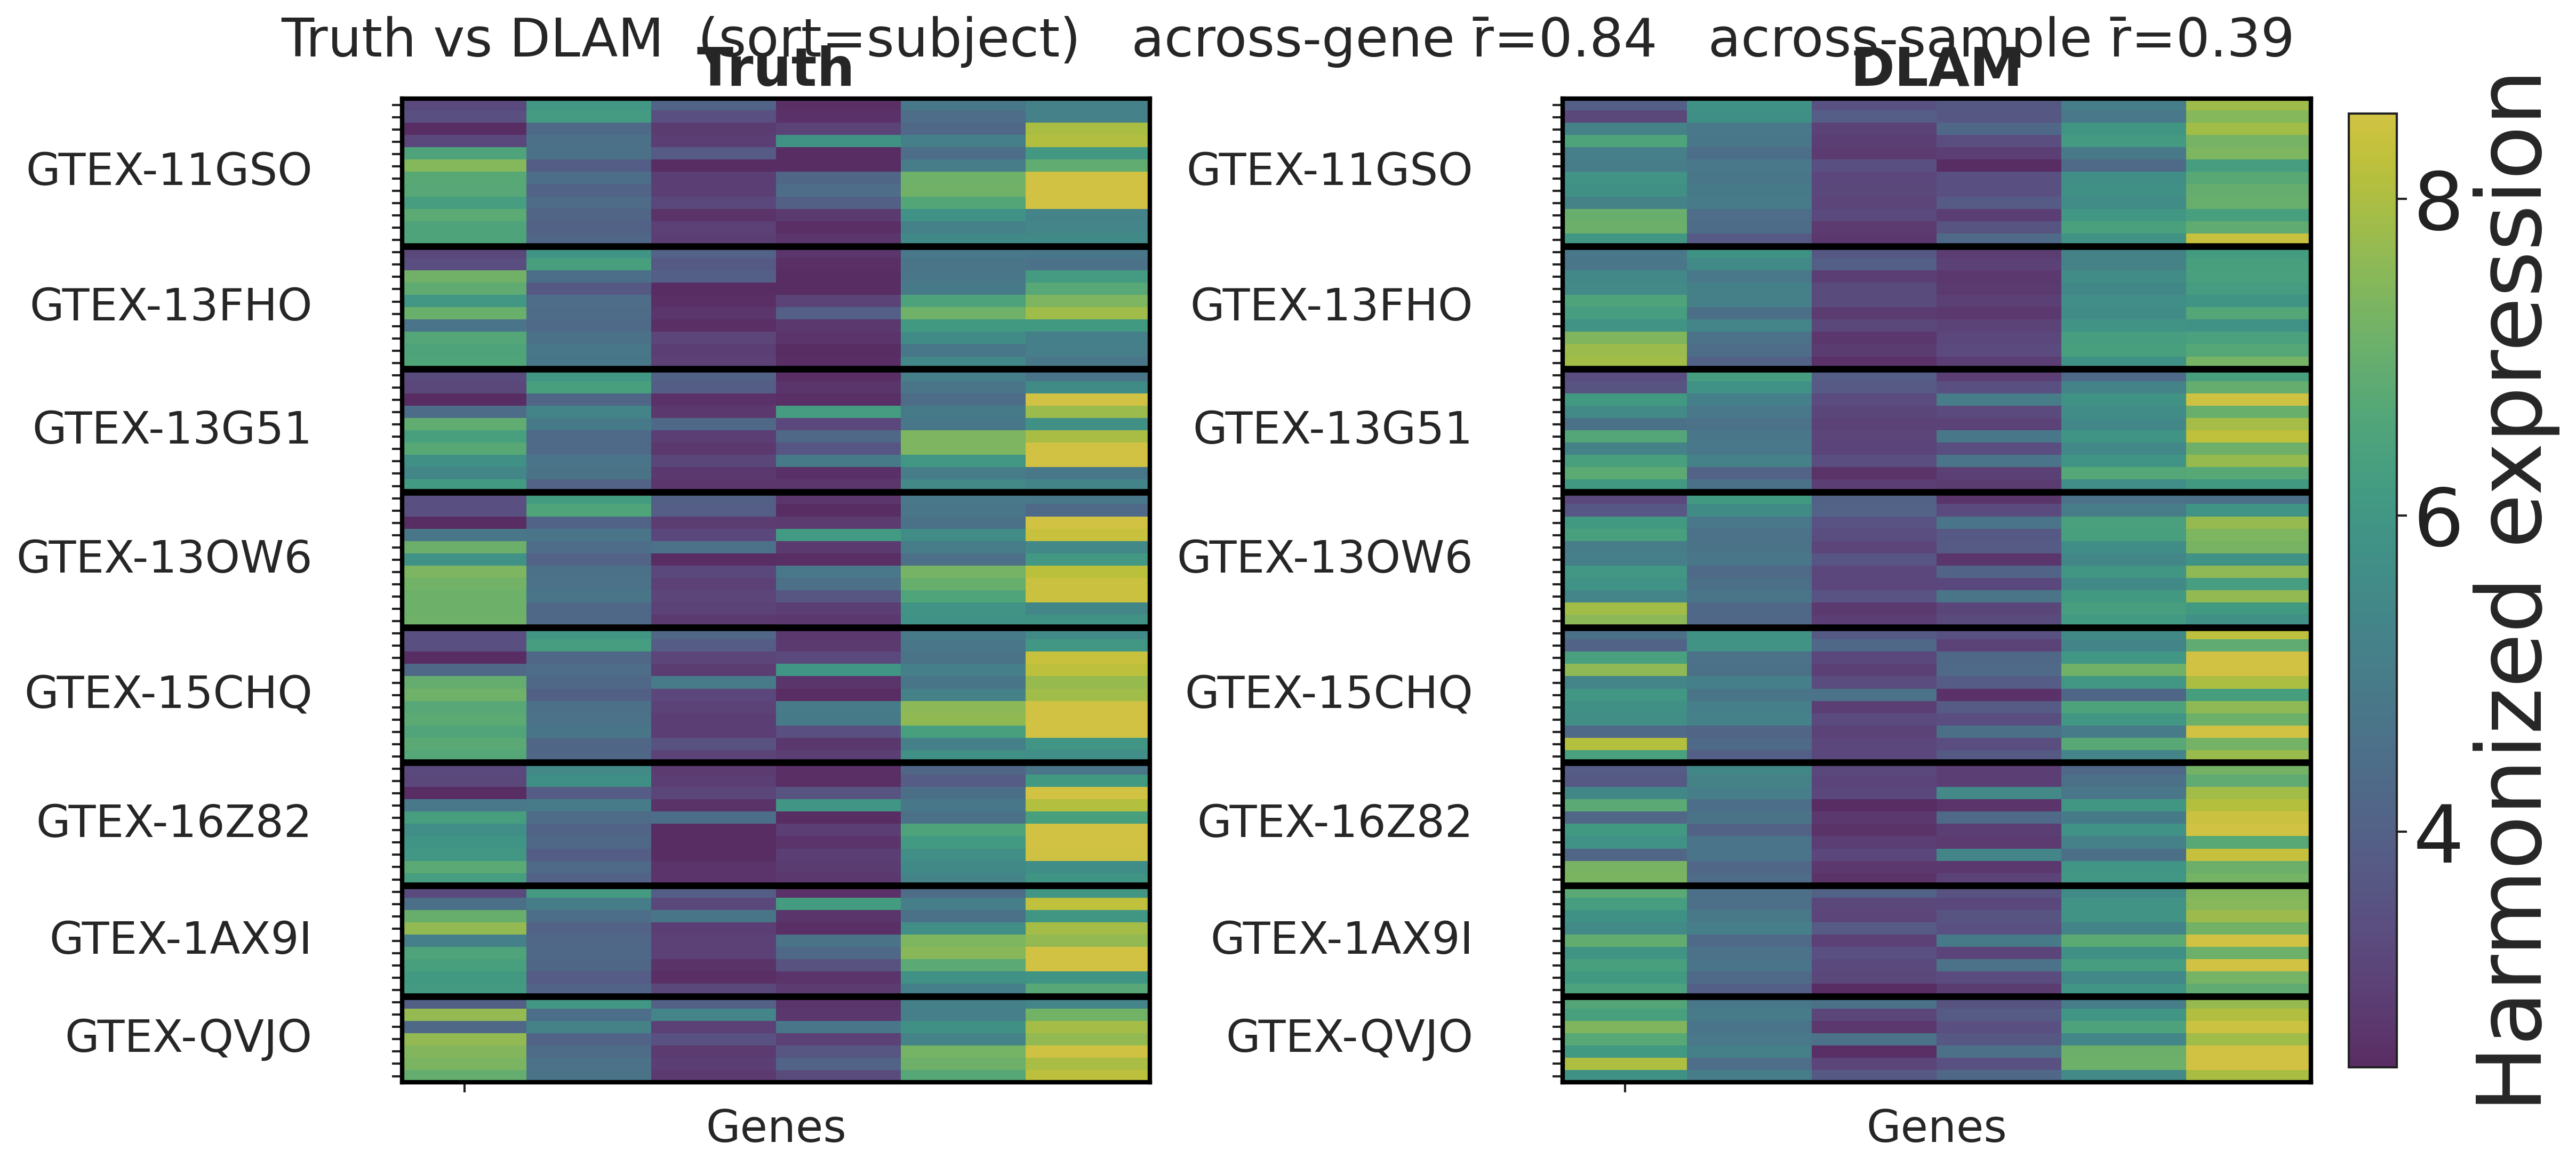

(<Figure size 4800x2100 with 3 Axes>,
 array([<Axes: title={'center': 'Truth'}, xlabel='Genes'>,
        <Axes: title={'center': 'DLAM'}, xlabel='Genes'>], dtype=object))

In [10]:
render_truth_vs('dlam')

### Truth vs Naive

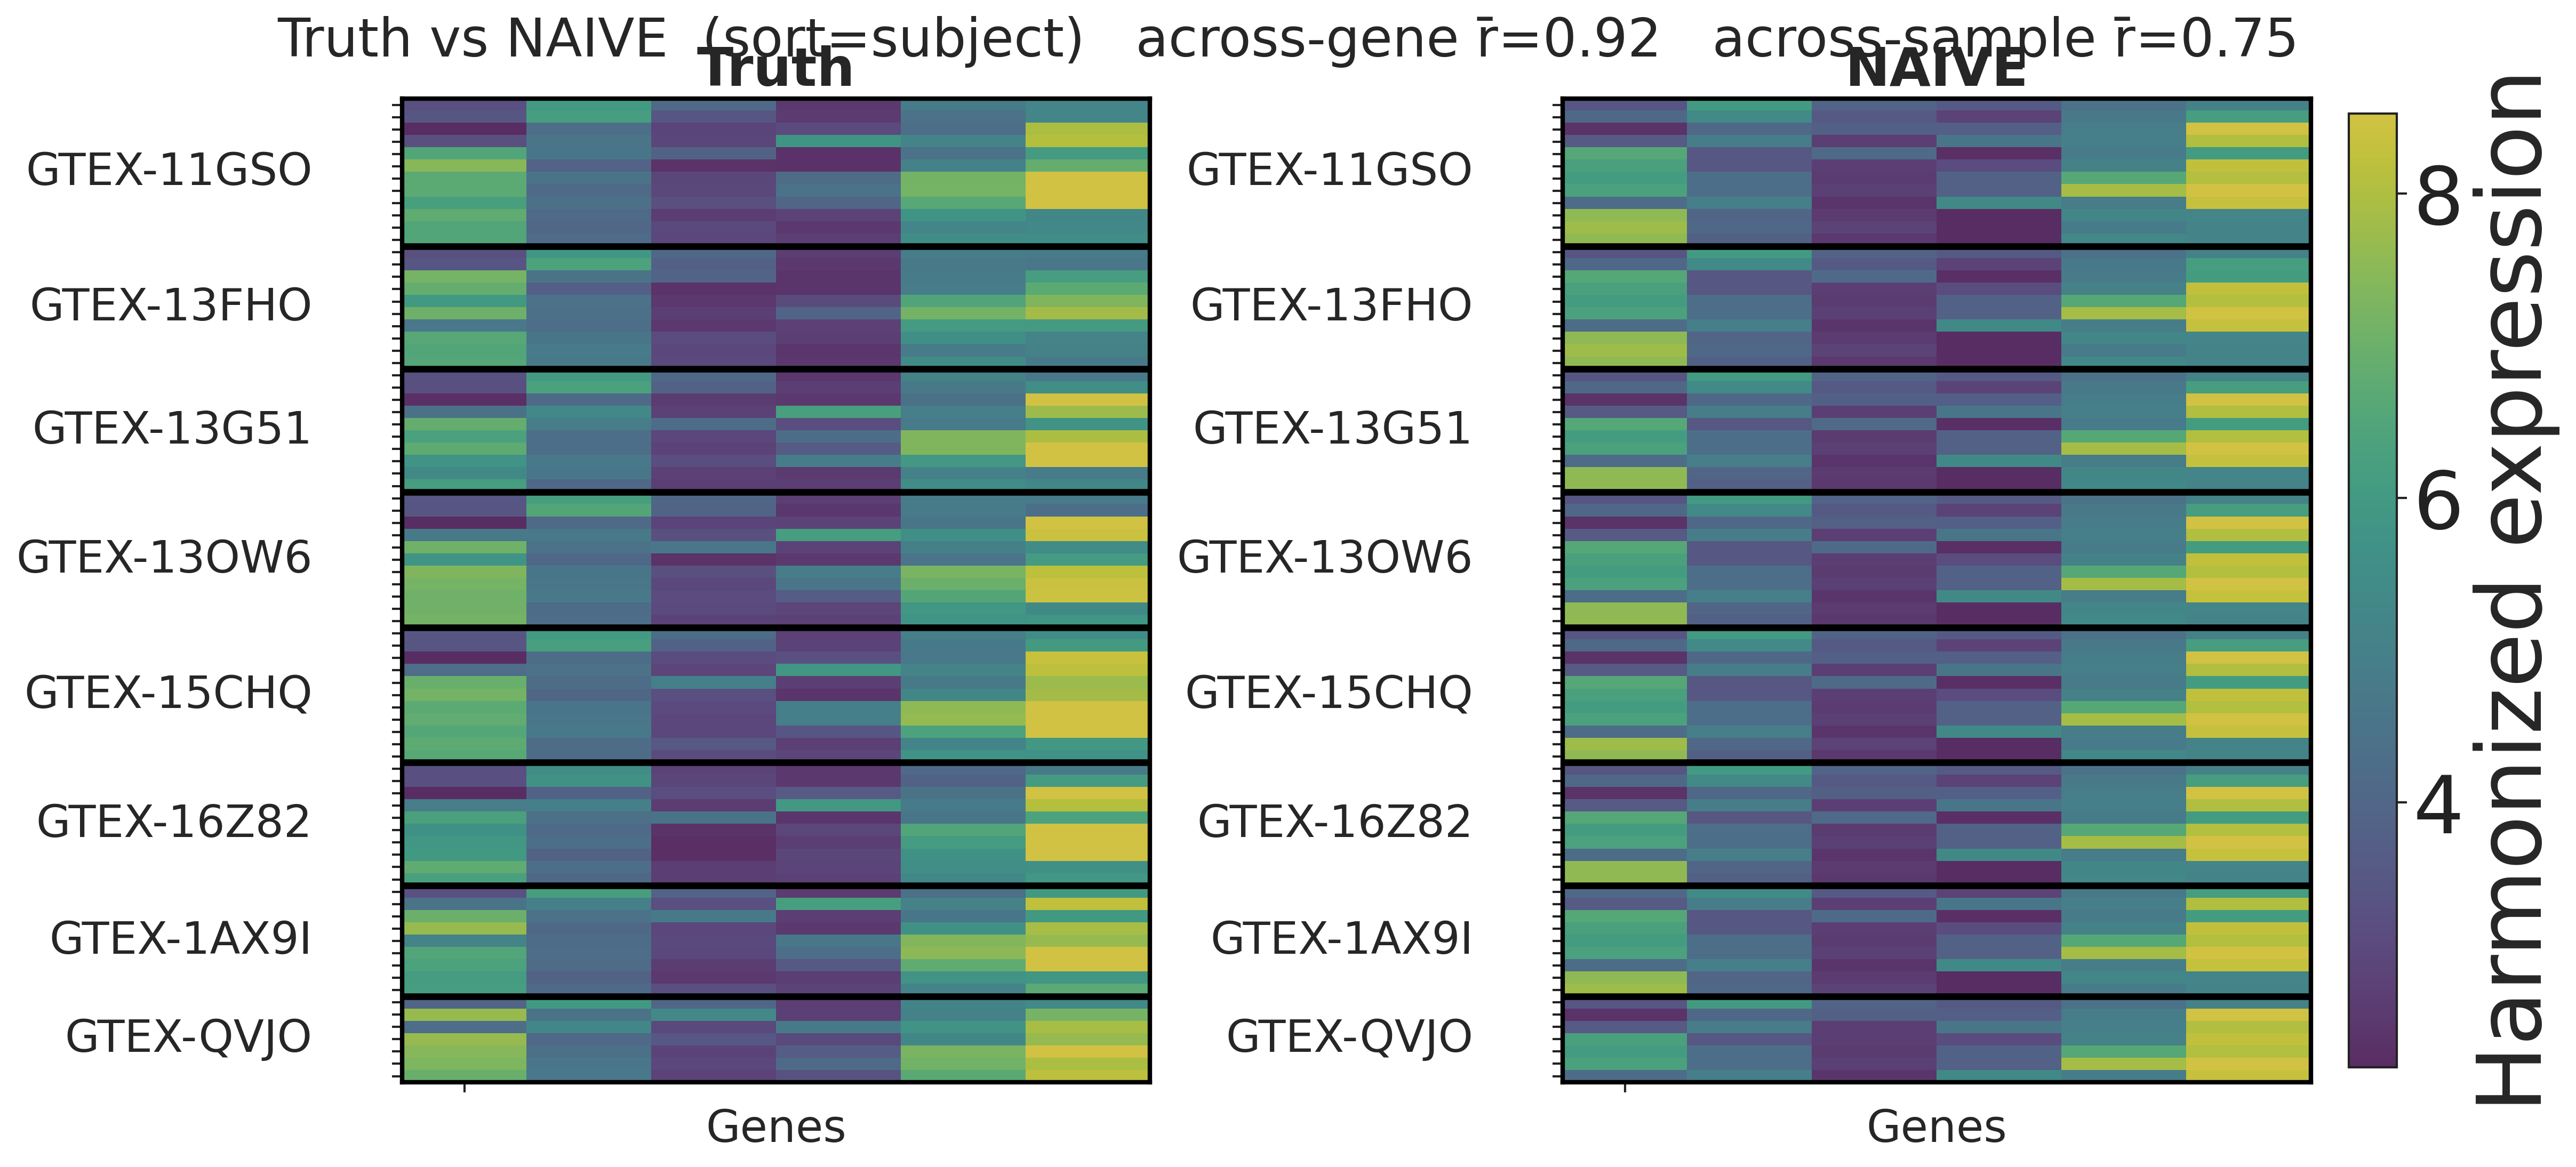

(<Figure size 4800x2100 with 3 Axes>,
 array([<Axes: title={'center': 'Truth'}, xlabel='Genes'>,
        <Axes: title={'center': 'NAIVE'}, xlabel='Genes'>], dtype=object))

In [11]:
render_truth_vs('naive')

## AHBA vs GTEx subject-wise comparison

Stacked GTEx **subject-wise** matrix (rows = subject-region samples, sorted by subject, region_matched order within each subject) next to a single AHBA **donor-median** matrix (region_matched_superset order, median across donors per region/gene). Both share the same gene axis as the matrix section above, so columns are directly comparable.

In [12]:
# === AHBA vs GTEx subject-wise — self-contained config (own plotting toggles) ===
# Independent of the Truth-vs-reconstruction section above: own gene panel/count, subjects, and
# every display knob. Gridlines (region/group separators) are OFF by default.

# Data / axes.
CMP_GTEX_STAGE = 'harmonized'          # GTEx subject-wise stage: 'harmonized' | 'raw_matched'
CMP_N_SUBJECTS = 8 if SMALL else 200   # GTEx subjects stacked in the subject-wise view
CMP_GENE_PANEL = 'richiardi2015'         # panel with >=100 genes (gtex_10deg only has 10)
CMP_N_GENES = 100                      # gene count for this section
CMP_RANDOM_SEED = 42
CMP_GROUPBY_GTEX = 'subject'           # stack rows by subject
CMP_GROUPBY_AHBA = 'tissue'            # label AHBA median rows by native tissue

# Display toggles (own).
CMP_SUBJECT_LABEL_MODE = 'full'
CMP_GENE_LABEL_MODE = 'full'
CMP_GENE_TICK_STEP = 10
CMP_SAMPLE_TICK_STEP = 1
CMP_SHOW_GENE_TICKLABELS = False
CMP_SHOW_SAMPLE_TICKLABELS = False
CMP_SHOW_GROUP_LABELS = True
CMP_SHOW_GROUP_SEPARATORS = False      # gridlines off by default
CMP_SHOW_REGION_SEPARATORS = False     # gridlines off by default
CMP_REGION_SEPARATOR_LINEWIDTH = 1.4
CMP_REGION_SEPARATOR_COLOR = '#808080'
CMP_REGION_SEPARATOR_ALPHA = 0.7
CMP_SHOW_YLABEL = False
CMP_GROUP_LABEL_X = -0.10
CMP_GROUP_LABEL_FONTSIZE = 8
CMP_CMAP = 'viridis'
CMP_SOFTEN = True
CMP_SOFTEN_AMOUNT = 0.35
CMP_SHARED_COLOR_SCALE = True
CMP_FIGSIZE = (20, 7)
CMP_NCOLS = 2
CMP_DPI = 300
CMP_FONT_SCALE = 2.0
CMP_CBAR_FONT_SCALE = 2.0
CMP_BORDER_LINEWIDTH = 2.0

In [13]:
# GTEx subject-wise: rows = (subject, region), grouped/sorted by subject,
# canonical region_matched order within each subject. Own gene selection.
gtex_subjwise_view = build_combat_tensor_view(
    prepost, dataset='GTEx', stage=CMP_GTEX_STAGE,
    cfg=cfg, matching_context=ctx,
    region_ordering='region_matched',
    gene_panel=CMP_GENE_PANEL, n_genes=CMP_N_GENES,
    n_subjects=CMP_N_SUBJECTS, random_seed=CMP_RANDOM_SEED,
)
gtex_subjwise_flat = build_flattened_tensor_matrix(
    gtex_subjwise_view,
    groupby=CMP_GROUPBY_GTEX,
    subject_label_mode=CMP_SUBJECT_LABEL_MODE,
    title=f'GTEx subject-wise ({CMP_GTEX_STAGE})',
    value_label='Expression',
)

# AHBA donor median: rows = regions in region_matched_superset order, median
# across donors per region/gene; gene axis pinned to the GTEx view so columns match.
ahba_super_view = build_combat_tensor_view(
    prepost, dataset='AHBA', stage='harmonized',
    cfg=cfg, matching_context=ctx,
    region_ordering='region_matched_superset',
    gene_panel=list(gtex_subjwise_view.genes), n_genes=None,
    random_seed=CMP_RANDOM_SEED,
)
ahba_median_flat = build_donor_median_flattened_matrix(
    ahba_super_view,
    groupby=CMP_GROUPBY_AHBA,
    title='AHBA donor median (superset)',
    value_label='Median expression',
)
assert list(gtex_subjwise_flat.genes) == list(ahba_median_flat.genes), 'gene axes must match'
print(f'GTEx subject-wise: rows={gtex_subjwise_flat.X.shape[0]}, genes={gtex_subjwise_flat.X.shape[1]}')
print(f'AHBA donor median: regions={ahba_median_flat.X.shape[0]}, genes={ahba_median_flat.X.shape[1]}')

GTEx subject-wise: rows=69, genes=97
AHBA donor median: regions=150, genes=97


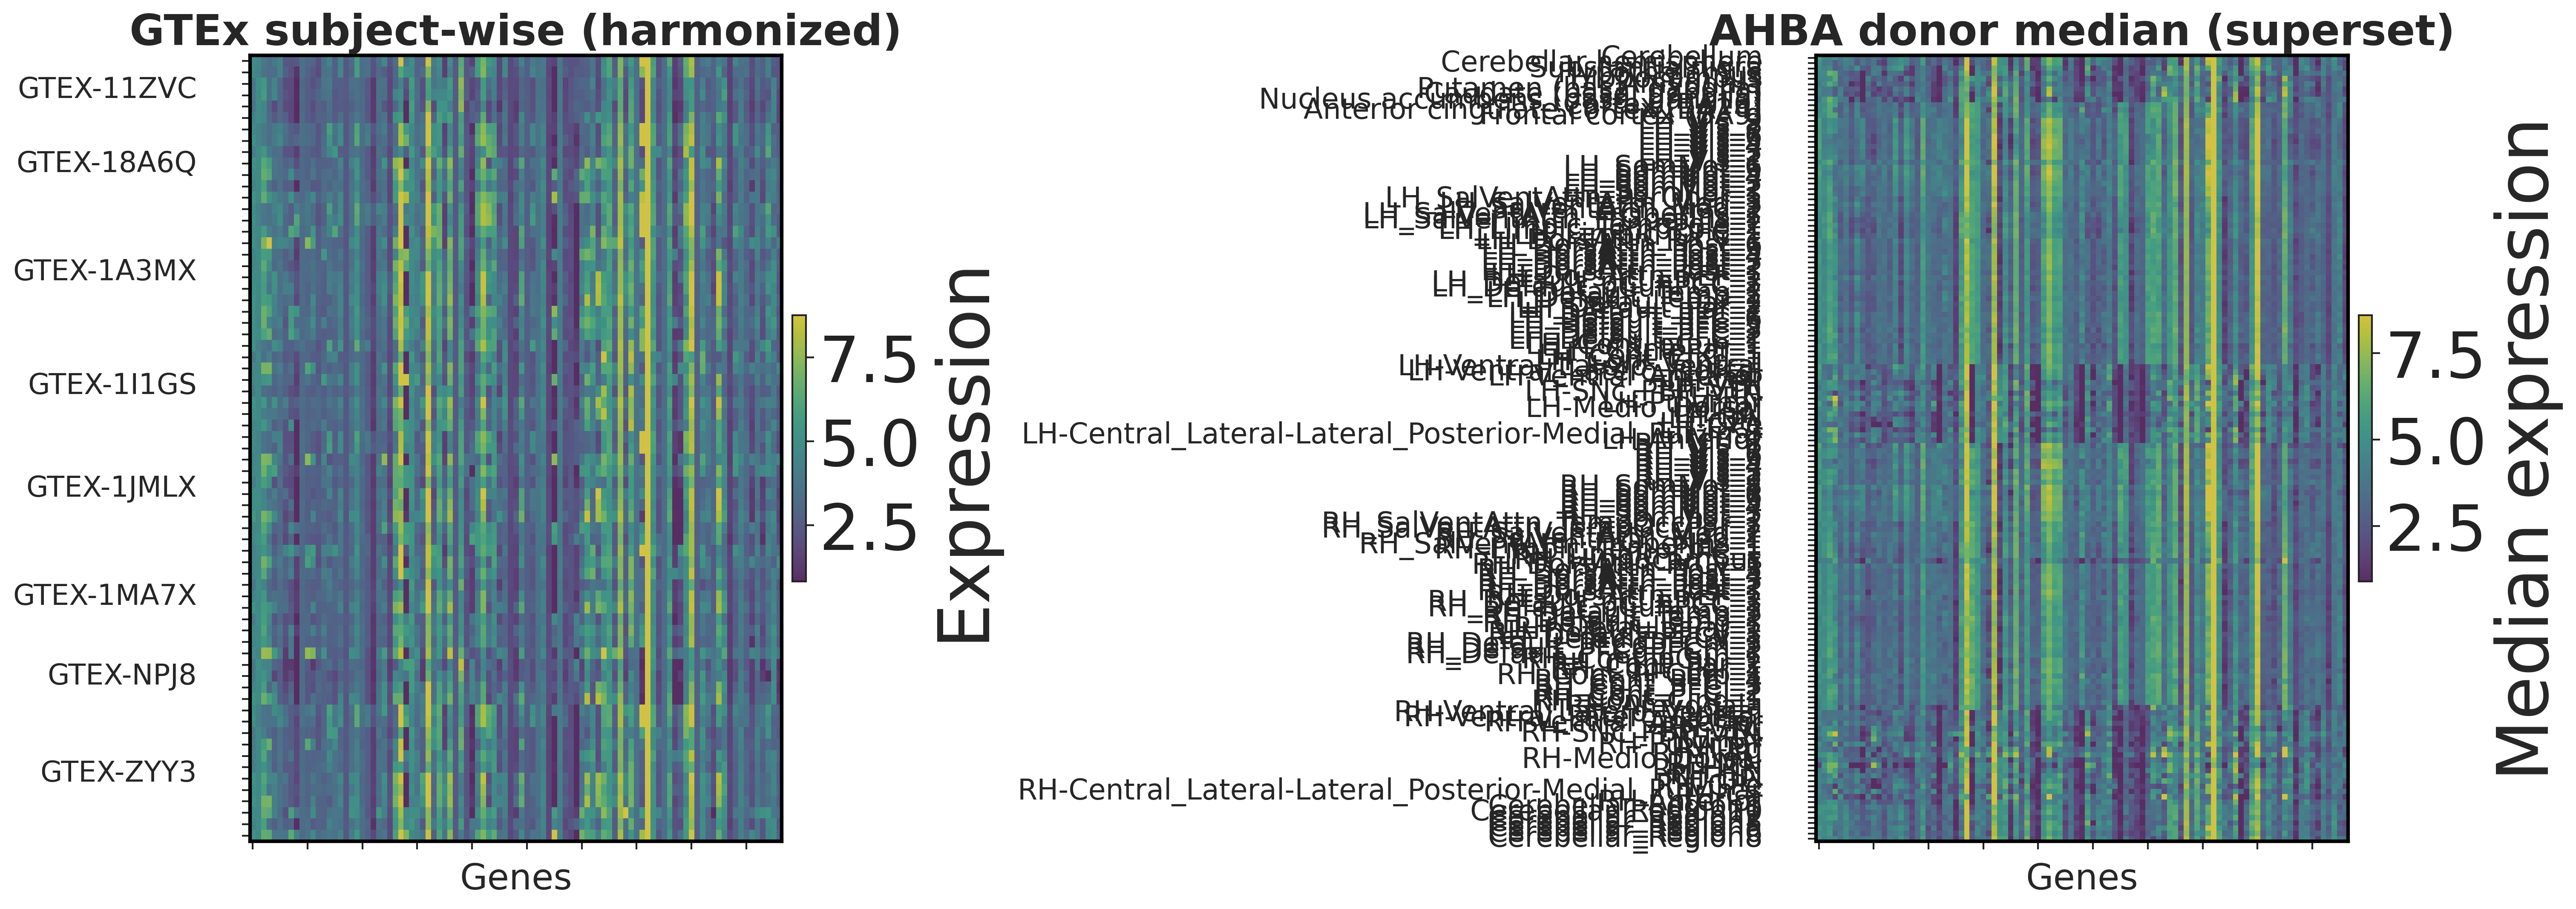

In [14]:
fig, axes = plot_flattened_tensor_matrices(
    [gtex_subjwise_flat],
    standalone_matrices=[ahba_median_flat],
    ncols=CMP_NCOLS,
    figsize=CMP_FIGSIZE,
    cmap=CMP_CMAP,
    shared_color_scale=CMP_SHARED_COLOR_SCALE,
    soften=CMP_SOFTEN,
    soften_amount=CMP_SOFTEN_AMOUNT,
    suptitle=None,
    gene_tick_step=CMP_GENE_TICK_STEP,
    sample_tick_step=CMP_SAMPLE_TICK_STEP,
    gene_label_mode=CMP_GENE_LABEL_MODE,
    show_gene_ticklabels=CMP_SHOW_GENE_TICKLABELS,
    show_sample_ticklabels=CMP_SHOW_SAMPLE_TICKLABELS,
    show_group_labels=CMP_SHOW_GROUP_LABELS,
    show_group_separators=CMP_SHOW_GROUP_SEPARATORS,
    show_region_separators=CMP_SHOW_REGION_SEPARATORS,
    region_separator_linewidth=CMP_REGION_SEPARATOR_LINEWIDTH,
    region_separator_color=CMP_REGION_SEPARATOR_COLOR,
    region_separator_alpha=CMP_REGION_SEPARATOR_ALPHA,
    show_ylabel=CMP_SHOW_YLABEL,
    group_label_x=CMP_GROUP_LABEL_X,
    group_label_fontsize=CMP_GROUP_LABEL_FONTSIZE,
    font_scale=CMP_FONT_SCALE,
    cbar_font_scale=CMP_CBAR_FONT_SCALE,
    border_linewidth=CMP_BORDER_LINEWIDTH,
    dpi=CMP_DPI,
)
plt.show()

## Notes

- Matched axis (`region_matched`): only the directly-comparable native GTEx parcels; no AHBA-only superset block, so nothing renders as future-imputed here.
- `loro_truth` is sparse along the parcel axis (only strictly-LORO-evaluated parcels carry truth); the rest renders as `Missing` gray. `loro_recon` is the held-out prediction at those same cells.
- Dense region ticks (`REGION_TICK_STEP=1`) label every parcel; switch `MODEL_NAME` to compare model families.